## 0. Configuration

In [44]:
pip install earthengine-api geemap pandas numpy matplotlib seaborn

In [ ]:
import json, time, re, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ee, geemap

STATE    = 'California'   # 'Arkansas' or 'California'
YEAR     = 2021
DATA_DIR = Path('.')
OUT_DIR  = Path('.')


ERA5_BANDS = [
    'temperature_2m',           # <- 1st climate attribute
    'total_precipitation_sum',  # <- 2nd climate attribute
    'dewpoint_temperature_2m',  # <- 3rd climate attribute
]


ERA5_OUT_PREFIX = {
    'temperature_2m'          : 'clim_temp_mean_C',
    'temperature_2m_min'      : 'clim_temp_min_C',
    'temperature_2m_max'      : 'clim_temp_max_C',
    'dewpoint_temperature_2m' : 'clim_dewpoint_mean_C',
    'total_precipitation_sum' : 'clim_precip_sum_m',   
    'surface_pressure'        : 'clim_surface_pressure_Pa',
    'mean_sea_level_pressure' : 'clim_sealevel_pressure_Pa',
}

# ── Build 36 × 10-day period boundaries (matching Sentinel-2 steps) ──────────
#
# GEE filterDate(start, end) is [start, end) — end is exclusive.
# t01 = Jan 01–10, t02 = Jan 11–20, …, t36 = Dec 17–26.
_origin = datetime.date(YEAR, 1, 1)
PERIODS = []
for i in range(36):
    ps = _origin + datetime.timedelta(days=i * 10)
    pe = _origin + datetime.timedelta(days=(i + 1) * 10)
    PERIODS.append((f't{i+1:02d}', ps.strftime('%Y-%m-%d'), pe.strftime('%Y-%m-%d')))

print(f'State  : {STATE} | Year : {YEAR}')
print(f'ERA5 bands selected : {ERA5_BANDS}')
print(f'Output prefixes     : {[ERA5_OUT_PREFIX[b] for b in ERA5_BANDS]}')
print(f'Temporal periods    : {len(PERIODS)}  ({PERIODS[0][0]} {PERIODS[0][1]} … {PERIODS[-1][0]} {PERIODS[-1][2]})')
print(f'Total climate cols  : {len(ERA5_BANDS) * len(PERIODS)}  '
      f'({len(ERA5_BANDS)} bands × {len(PERIODS)} periods)')

LABEL_MAP = {
    'Arkansas':   {0: 'Soybeans', 1: 'Rice', 2: 'Corn', 3: 'Cotton',    4: 'Others'},
    'California': {0: 'Grapes',   1: 'Rice', 2: 'Alfalfa', 3: 'Almonds', 4: 'Pistachios', 5: 'Others'},
}
label_map = LABEL_MAP[STATE]

State  : California | Year : 2021
ERA5 bands selected : ['temperature_2m', 'total_precipitation_sum', 'dewpoint_temperature_2m']
Output prefixes     : ['clim_temp_mean_C', 'clim_precip_sum_m', 'clim_dewpoint_mean_C']
Temporal periods    : 36  (t01 2021-01-01 … t36 2021-12-27)
Total climate cols  : 108  (3 bands × 36 periods)


## 1. GEE Authentication & Initialization

In [ ]:
try:
    ee.Initialize(project='crop-mapping-usa-2025')  
    print('GEE initialized successfully.')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='crop-mapping-usa-2025')
    print('GEE authenticated and initialized.')

GEE initialized successfully.


## 2. Load the Existing Dataset & Build a GEE FeatureCollection

In [47]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/MCTNet_Data'
files  = sorted(os.listdir(FOLDER))
print(f'Files in folder: {files}')

df_ar = pd.read_csv(os.path.join(FOLDER, 'MCTNet_Arkansas_2021_fixed.csv'))
df_ca = pd.read_csv(os.path.join(FOLDER, 'MCTNet_California_2021_fixed.csv'))
df    = pd.read_csv(os.path.join(FOLDER, f'MCTNet_{STATE}_{YEAR}_fixed.csv'))

print(f'Arkansas Data   : {len(df_ar):,} rows × {df_ar.shape[1]} cols')
print(f'California Data : {len(df_ca):,} rows × {df_ca.shape[1]} cols')
print(f'Working dataset : {len(df):,} rows × {df.shape[1]} cols')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in folder: ['MCTNet_Arkansas_2021_ERA5.csv', 'MCTNet_Arkansas_2021_Soil.csv', 'MCTNet_Arkansas_2021_Topo.csv', 'MCTNet_Arkansas_2021_enriched.csv', 'MCTNet_Arkansas_2021_fixed.csv', 'MCTNet_California_2021_ERA5.csv', 'MCTNet_California_2021_Soil.csv', 'MCTNet_California_2021_Topo.csv', 'MCTNet_California_2021_enriched.csv', 'MCTNet_California_2021_fixed.csv']
Arkansas Data   : 10,000 rows × 403 cols
California Data : 10,000 rows × 403 cols
Working dataset : 10,000 rows × 403 cols


In [48]:
import pandas as pd, json as _json

def parse_geo(geo_str):
    try:
        coords = _json.loads(geo_str)['coordinates']
        return float(coords[0]), float(coords[1])
    except Exception:
        return float('nan'), float('nan')

parsed    = df['.geo'].apply(parse_geo).tolist()
df        = df.copy()
df['lon'] = [p[0] for p in parsed]
df['lat'] = [p[1] for p in parsed]

n_before = len(df)
df.dropna(subset=['lon', 'lat'], inplace=True)
print(f'Parsed {len(df):,} valid coordinates (dropped {n_before - len(df)} invalid).')
print(f'Lon: {df.lon.min():.4f} -> {df.lon.max():.4f}')
print(f'Lat: {df.lat.min():.4f} -> {df.lat.max():.4f}')

Parsed 10,000 valid coordinates (dropped 0 invalid).
Lon: -124.2553 -> -114.5113
Lat: 32.5889 -> 41.9961


In [49]:
def build_feature_collection(df_chunk):
    features = []
    for _, row in df_chunk.iterrows():
        point = ee.Geometry.Point([row['lon'], row['lat']])
        feat  = ee.Feature(point, {'sample_id': int(row['sample_id'])})
        features.append(feat)
    return ee.FeatureCollection(features)

half       = len(df) // 2
batch_A    = build_feature_collection(df.iloc[:half])
batch_B    = build_feature_collection(df.iloc[half:])
all_points = batch_A.merge(batch_B)

print(f'GEE FeatureCollection built: {len(df):,} points (2 batches).')

GEE FeatureCollection built: 10,000 points (2 batches).


## 3. Climate Features — ERA5-Land (Per-10-Day-Period Aggregates)

In [ ]:
ERA5_COLLECTION = 'ECMWF/ERA5_LAND/DAILY_AGGR'

# Safety check: verify the collection covers YEAR
n_images = (
    ee.ImageCollection(ERA5_COLLECTION)
    .filterDate(f'{YEAR}-01-01', f'{YEAR+1}-01-01')
    .size().getInfo()
)
print(f'ERA5_LAND images found for {YEAR}: {n_images}')
if n_images == 0:
    raise RuntimeError(f'Empty collection! Check {ERA5_COLLECTION} availability for {YEAR}.')

# Build one multi-band image containing all 36×len(ERA5_BANDS) bands 

precip_bands    = [b for b in ERA5_BANDS if 'precipitation' in b]
nonprecip_bands = [b for b in ERA5_BANDS if 'precipitation' not in b]

era5_band_images = []   # list of single-band ee.Image objects
era5_band_names  = []   # matching output column names

for period_id, pstart, pend in PERIODS:
    period_col = (
        ee.ImageCollection(ERA5_COLLECTION)
        .filterDate(pstart, pend)
        .select(ERA5_BANDS)
    )

    # Aggregate within the 10-day window
    agg_mean = period_col.select(nonprecip_bands).mean() if nonprecip_bands else None
    agg_sum  = period_col.select(precip_bands).sum()     if precip_bands    else None

    for b in ERA5_BANDS:
        prefix   = ERA5_OUT_PREFIX.get(b, f'clim_{b}')
        col_name = f'{prefix}_{period_id}'           # e.g. clim_temp_mean_C_t03
        src_img  = agg_sum if ('precipitation' in b) else agg_mean
        era5_band_images.append(src_img.select(b).rename(col_name))
        era5_band_names.append(col_name)

# Concatenate into a single multi-band image
era5_image = ee.Image.cat(era5_band_images)

print(f'ERA5 image: {len(era5_band_names)} bands')
print(f'  First 6 : {era5_band_names[:6]}')
print(f'  Last  6 : {era5_band_names[-6:]}')

ERA5_LAND images found for 2021: 365
ERA5 image: 108 bands
  First 6 : ['clim_temp_mean_C_t01', 'clim_precip_sum_m_t01', 'clim_dewpoint_mean_C_t01', 'clim_temp_mean_C_t02', 'clim_precip_sum_m_t02', 'clim_dewpoint_mean_C_t02']
  Last  6 : ['clim_temp_mean_C_t35', 'clim_precip_sum_m_t35', 'clim_dewpoint_mean_C_t35', 'clim_temp_mean_C_t36', 'clim_precip_sum_m_t36', 'clim_dewpoint_mean_C_t36']


In [ ]:
#  Extract ERA5 values at all sample points 

era5_samples = era5_image.sampleRegions(
    collection = all_points,
    properties = ['sample_id'],
    scale      = 9000,        
    projection = 'EPSG:4326',
    tileScale  = 4,
    geometries = False
)

task_era5 = ee.batch.Export.table.toDrive(
    collection     = era5_samples,
    description    = f'MCTNet_{STATE}_{YEAR}_ERA5_10day',
    folder         = 'MCTNet_GEE_Exports',
    fileNamePrefix = f'MCTNet_{STATE}_{YEAR}_ERA5_10day',
    fileFormat     = 'CSV'
)
task_era5.start()
print(f'ERA5 export task submitted: MCTNet_{STATE}_{YEAR}_ERA5_10day.csv')
print(f'Task ID : {task_era5.id}')
print('Monitor : https://code.earthengine.google.com/tasks')
print(f'Expected columns in output: {len(era5_band_names)} climate + 1 sample_id')

ERA5 export task submitted: MCTNet_California_2021_ERA5_10day.csv
Task ID : OTZQ4XH2DU2CYXI5AGU2OFPB
Monitor : https://code.earthengine.google.com/tasks
Expected columns in output: 108 climate + 1 sample_id


## 4. Soil Features — OpenLandMap (3 attributes)

In [ ]:
soil_ph = (
    ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02')
    .select('b0')
    .rename('soil_pH_x10')
)

soil_oc = (
    ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02')
    .select('b0')
    .rename('soil_organic_carbon_g_kg')
)

soil_texture = (
    ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02')
    .select('b0')
    .rename('soil_texture_class')
)

soil_image = ee.Image.cat([soil_ph, soil_oc, soil_texture])
print('Soil image bands:', soil_image.bandNames().getInfo())

In [ ]:
soil_samples = soil_image.sampleRegions(
    collection = all_points,
    properties = ['sample_id'],
    scale      = 250,
    projection = 'EPSG:4326',
    tileScale  = 2,
    geometries = False
)

task_soil = ee.batch.Export.table.toDrive(
    collection     = soil_samples,
    description    = f'MCTNet_{STATE}_{YEAR}_Soil',
    folder         = 'MCTNet_GEE_Exports',
    fileNamePrefix = f'MCTNet_{STATE}_{YEAR}_Soil',
    fileFormat     = 'CSV'
)
task_soil.start()
print(f'Soil export task submitted: MCTNet_{STATE}_{YEAR}_Soil.csv')

## 5. Topography Features — ETOPO1 & ALOS Landforms

In [ ]:
elevation = (
    ee.Image('NOAA/NGDC/ETOPO1')
    .select('bedrock')
    .rename('topo_elevation_m')
)

landforms = (
    ee.Image('CSP/ERGo/1_0/Global/ALOS_landforms')
    .select('constant')
    .rename('topo_landform_class')
)

topo_image = ee.Image.cat([elevation, landforms])
print('Topography image bands:', topo_image.bandNames().getInfo())

In [ ]:
topo_samples = topo_image.sampleRegions(
    collection = all_points,
    properties = ['sample_id'],
    scale      = 1000,
    projection = 'EPSG:4326',
    tileScale  = 2,
    geometries = False
)

task_topo = ee.batch.Export.table.toDrive(
    collection     = topo_samples,
    description    = f'MCTNet_{STATE}_{YEAR}_Topo',
    folder         = 'MCTNet_GEE_Exports',
    fileNamePrefix = f'MCTNet_{STATE}_{YEAR}_Topo',
    fileFormat     = 'CSV'
)
task_topo.start()
print(f'Topography export task submitted: MCTNet_{STATE}_{YEAR}_Topo.csv')

## 6. Monitor Export Tasks

In [ ]:
def check_tasks(tasks, interval_sec=30, max_wait_min=30):
    task_ids = {t.id: t for t in tasks}
    max_iter = (max_wait_min * 60) // interval_sec
    for iteration in range(max_iter):
        statuses = {tid: ee.data.getTaskStatus(tid)[0]['state'] for tid in task_ids}
        print(f'[Iter {iteration+1:02d}] ' + ' | '.join(f'{tid[-8:]}: {s}' for tid, s in statuses.items()))
        if all(s in ('COMPLETED', 'FAILED', 'CANCELLED') for s in statuses.values()):
            break
        time.sleep(interval_sec)
    for tid, status in statuses.items():
        icon = 'OK' if status == 'COMPLETED' else 'FAILED'
        print(f'  [{icon}] Task {tid[-8:]}: {status}')

# Quick one-shot status check:
for task in [task_era5, task_soil, task_topo]:
    status = ee.data.getTaskStatus(task.id)[0]['state']
    print(f'Task {task.id[-12:]}: {status}')

## 7. Load the 3 Exported Auxiliary CSVs

In [52]:
import os
print(os.listdir(DATA_DIR))

['.config', 'static_aux_distributions_Arkansas_2021.png', 'clim_temporal_profiles_Arkansas_2021.png', 'MCTNet_Arkansas_2021_enriched_fixed.csv', 'drive', 'sample_data']


In [ ]:
from pathlib import Path

DATA_DIR = Path('/content/drive/My Drive/MCTNet_GEE_Exports')

print(f'Loading auxiliary CSVs for {STATE} {YEAR}...')
df_era5 = load_aux('ERA5_10day', STATE, YEAR, DATA_DIR)
df_soil = load_aux('Soil',       STATE, YEAR, DATA_DIR)
df_topo = load_aux('Topo',       STATE, YEAR, DATA_DIR)

Loading auxiliary CSVs for California 2021...
  ERA5_10day     : 9,993 rows, 111 cols
  Soil           : 9,985 rows, 6 cols
  Topo           : 10,000 rows, 5 cols


## 8. Merge All Features into the Main Dataset

In [54]:
def clean_aux(df, feature_cols, join_col='sample_id'):
    cols    = [join_col] + [c for c in feature_cols if c in df.columns]
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        print(f'  WARNING: columns not found: {missing[:5]} …')
    return df[cols].copy()

# ERA5 — pick all clim_ columns (now 36 × len(ERA5_BANDS) = 108 cols)
era5_cols = [c for c in df_era5.columns if c.startswith('clim_')]
print(f'ERA5 climate columns found: {len(era5_cols)}')
print(f'  Sample: {era5_cols[:4]} … {era5_cols[-4:]}')
df_era5_c = clean_aux(df_era5, era5_cols)

# Soil
soil_cols = ['soil_pH_x10', 'soil_organic_carbon_g_kg', 'soil_texture_class']
df_soil_c = clean_aux(df_soil, soil_cols)

# Topography
topo_cols = ['topo_elevation_m', 'topo_landform_class']
df_topo_c = clean_aux(df_topo, topo_cols)

# Base Sentinel-2 dataset
base = pd.read_csv(DATA_DIR / f'MCTNet_{STATE}_{YEAR}_fixed.csv')
print(f'\nBase dataset : {len(base):,} rows × {base.shape[1]} cols')

enriched = (
    base
    .merge(df_era5_c, on='sample_id', how='left')
    .merge(df_soil_c, on='sample_id', how='left')
    .merge(df_topo_c, on='sample_id', how='left')
)

print(f'Enriched dataset : {len(enriched):,} rows × {enriched.shape[1]} cols')
print(f'New columns added: {len(era5_cols) + len(soil_cols) + len(topo_cols)}')

ERA5 climate columns found: 108
  Sample: ['clim_dewpoint_mean_C_t01', 'clim_dewpoint_mean_C_t02', 'clim_dewpoint_mean_C_t03', 'clim_dewpoint_mean_C_t04'] … ['clim_temp_mean_C_t33', 'clim_temp_mean_C_t34', 'clim_temp_mean_C_t35', 'clim_temp_mean_C_t36']

Base dataset : 10,000 rows × 403 cols
Enriched dataset : 10,000 rows × 516 cols
New columns added: 113


In [ ]:
# Unit conversions 

for col in list(enriched.columns):
    if col.startswith('clim_') and col.endswith(tuple(f'_t{i:02d}' for i in range(1,37))):
        # Check if this column was produced from a temperature/dewpoint band
        # (precipitation columns keep their raw meter values — no conversion needed)
        if 'precip' not in col:
            # Values are in Kelvin from GEE; subtract 273.15
            enriched[col] = enriched[col] - 273.15

print('Temperature/dewpoint columns converted from K to °C.')

# Soil pH: x10 encoding → real pH
if 'soil_pH_x10' in enriched.columns:
    enriched['soil_pH'] = enriched['soil_pH_x10'] / 10.0
    enriched.drop(columns=['soil_pH_x10'], inplace=True)
    print('Converted soil_pH_x10 → soil_pH.')

# Final auxiliary column list
aux_cols = [c for c in enriched.columns if c.startswith(('clim_', 'soil_', 'topo_'))]
print(f'\nTotal auxiliary features : {len(aux_cols)}')
print(f'  Climate (per-period)   : {len([c for c in aux_cols if c.startswith("clim_")])}')
print(f'  Soil (static)          : {len([c for c in aux_cols if c.startswith("soil_")])}')
print(f'  Topography (static)    : {len([c for c in aux_cols if c.startswith("topo_")])}')

Temperature/dewpoint columns converted from K to °C.
Converted soil_pH_x10 → soil_pH.

Total auxiliary features : 113
  Climate (per-period)   : 108
  Soil (static)          : 3
  Topography (static)    : 2


In [56]:
# Missing value check & median imputation
print('Missing value count per auxiliary feature:')
mv = enriched[aux_cols].isnull().sum()
nonzero = mv[mv > 0]
if len(nonzero) == 0:
    print('  All OK — no missing values.')
else:
    for col, n in nonzero.items():
        pct = n / len(enriched) * 100
        print(f'  WARN: {col}: {n} missing ({pct:.1f}%)')
        median_val = enriched[col].median()
        enriched[col].fillna(median_val, inplace=True)

Missing value count per auxiliary feature:
  WARN: clim_dewpoint_mean_C_t01: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t02: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t03: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t04: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t05: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t06: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t07: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t08: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t09: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t10: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t11: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t12: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t13: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t14: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t15: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t16: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t17: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t18: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t19: 7 mis

/tmp/ipykernel_1956/4067294912.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  enriched[col].fillna(median_val, inplace=True)


In [ ]:
import pandas as pd
import numpy as np

def clean_aux(df, feature_cols, join_col='sample_id'):
    cols = [join_col] + [c for c in feature_cols if c in df.columns]
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        print(f'  WARNING: columns not found: {missing[:5]} …')
    return df[cols].copy()

# 1. Prepare Columns
era5_cols = [c for c in df_era5.columns if c.startswith('clim_')]
df_era5_c = clean_aux(df_era5, era5_cols)

soil_cols = ['soil_pH_x10', 'soil_organic_carbon_g_kg', 'soil_texture_class']
df_soil_c = clean_aux(df_soil, soil_cols)

topo_cols = ['topo_elevation_m', 'topo_landform_class']
df_topo_c = clean_aux(df_topo, topo_cols)

# 2. Merge Data
base = pd.read_csv(DATA_DIR / f'MCTNet_{STATE}_{YEAR}_fixed.csv')
enriched = (
    base
    .merge(df_era5_c, on='sample_id', how='left')
    .merge(df_soil_c, on='sample_id', how='left')
    .merge(df_topo_c, on='sample_id', how='left')
)

# 3. Unit Conversions (Fixed Chained Assignment)
# Using .loc is the "safe" way to modify columns in place
temp_suffixes = tuple(f'_t{i:02d}' for i in range(1, 37))
for col in enriched.columns:
    if col.startswith('clim_') and col.endswith(temp_suffixes) and 'precip' not in col:
        # Subtracting 273.15 from Kelvin to get Celsius
        enriched[col] = enriched[col] - 273.15

print('Temperature/dewpoint columns converted from K to °C.')

if 'soil_pH_x10' in enriched.columns:
    enriched['soil_pH'] = enriched['soil_pH_x10'] / 10.0
    enriched.drop(columns=['soil_pH_x10'], inplace=True)
    print('Converted soil_pH_x10 → soil_pH.')

# 4. Handle Missing Values 
aux_cols = [c for c in enriched.columns if c.startswith(('clim_', 'soil_', 'topo_'))]
print('\nChecking missing values...')

mv = enriched[aux_cols].isnull().sum()
nonzero = mv[mv > 0]

if len(nonzero) == 0:
    print('  All OK — no missing values.')
else:
    for col, n in nonzero.items():
        pct = n / len(enriched) * 100
        print(f'  WARN: {col}: {n} missing ({pct:.1f}%)')
        
        median_val = enriched[col].median()
        enriched[col] = enriched[col].fillna(median_val)

print('Missing values handled using median imputation.')

Temperature/dewpoint columns converted from K to °C.
Converted soil_pH_x10 → soil_pH.

Checking missing values...
  WARN: clim_dewpoint_mean_C_t01: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t02: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t03: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t04: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t05: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t06: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t07: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t08: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t09: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t10: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t11: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t12: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t13: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t14: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t15: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t16: 7 missing (0.1%)
  WARN: clim_dewpoint_mean_C_t17: 7 missing (0.1%)
  WARN: clim_dewpoi

## 9. Save the Enriched Dataset

In [58]:
out_path = OUT_DIR / f'MCTNet_{STATE}_{YEAR}_enriched_fixed.csv'
enriched.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {enriched.shape[0]:,} rows × {enriched.shape[1]} cols')

spectral_cols = [c for c in enriched.columns if re.match(r'\w+_t\d{2}$', c) and not c.startswith(('valid_', 'clim_', 'soil_', 'topo_'))]
valid_cols    = [c for c in enriched.columns if c.startswith('valid_t')]
clim_cols     = [c for c in aux_cols if c.startswith('clim_')]
soil_topo_cols= [c for c in aux_cols if not c.startswith('clim_')]

print('\nColumn inventory:')
print(f'  Spectral features        : {len(spectral_cols):>4}   (10 bands × 36 steps)')
print(f'  Validity flags           : {len(valid_cols):>4}')
print(f'  Climate (per-period)     : {len(clim_cols):>4}   ({len(ERA5_BANDS)} bands × 36 steps)')
print(f'  Soil + Topography        : {len(soil_topo_cols):>4}   (static per sample)')
print(f'  ─────────────────────────────')
print(f'  Total model-ready feats  : {len(spectral_cols)+len(valid_cols)+len(aux_cols):>4}')

Saved: MCTNet_California_2021_enriched_fixed.csv
Shape: 10,000 rows × 516 cols

Column inventory:
  Spectral features        :  360   (10 bands × 36 steps)
  Validity flags           :   36
  Climate (per-period)     :  108   (3 bands × 36 steps)
  Soil + Topography        :    5   (static per sample)
  ─────────────────────────────
  Total model-ready feats  :  509


## 10. Validation — Climate Temporal Profile per Crop Class

Plot the mean temporal profile of each climate variable for each crop class
(analogous to Figure 2 NDVI profiles in the paper).

/tmp/ipykernel_1956/1691676101.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  enriched['crop_name'] = enriched['label'].map(label_map)


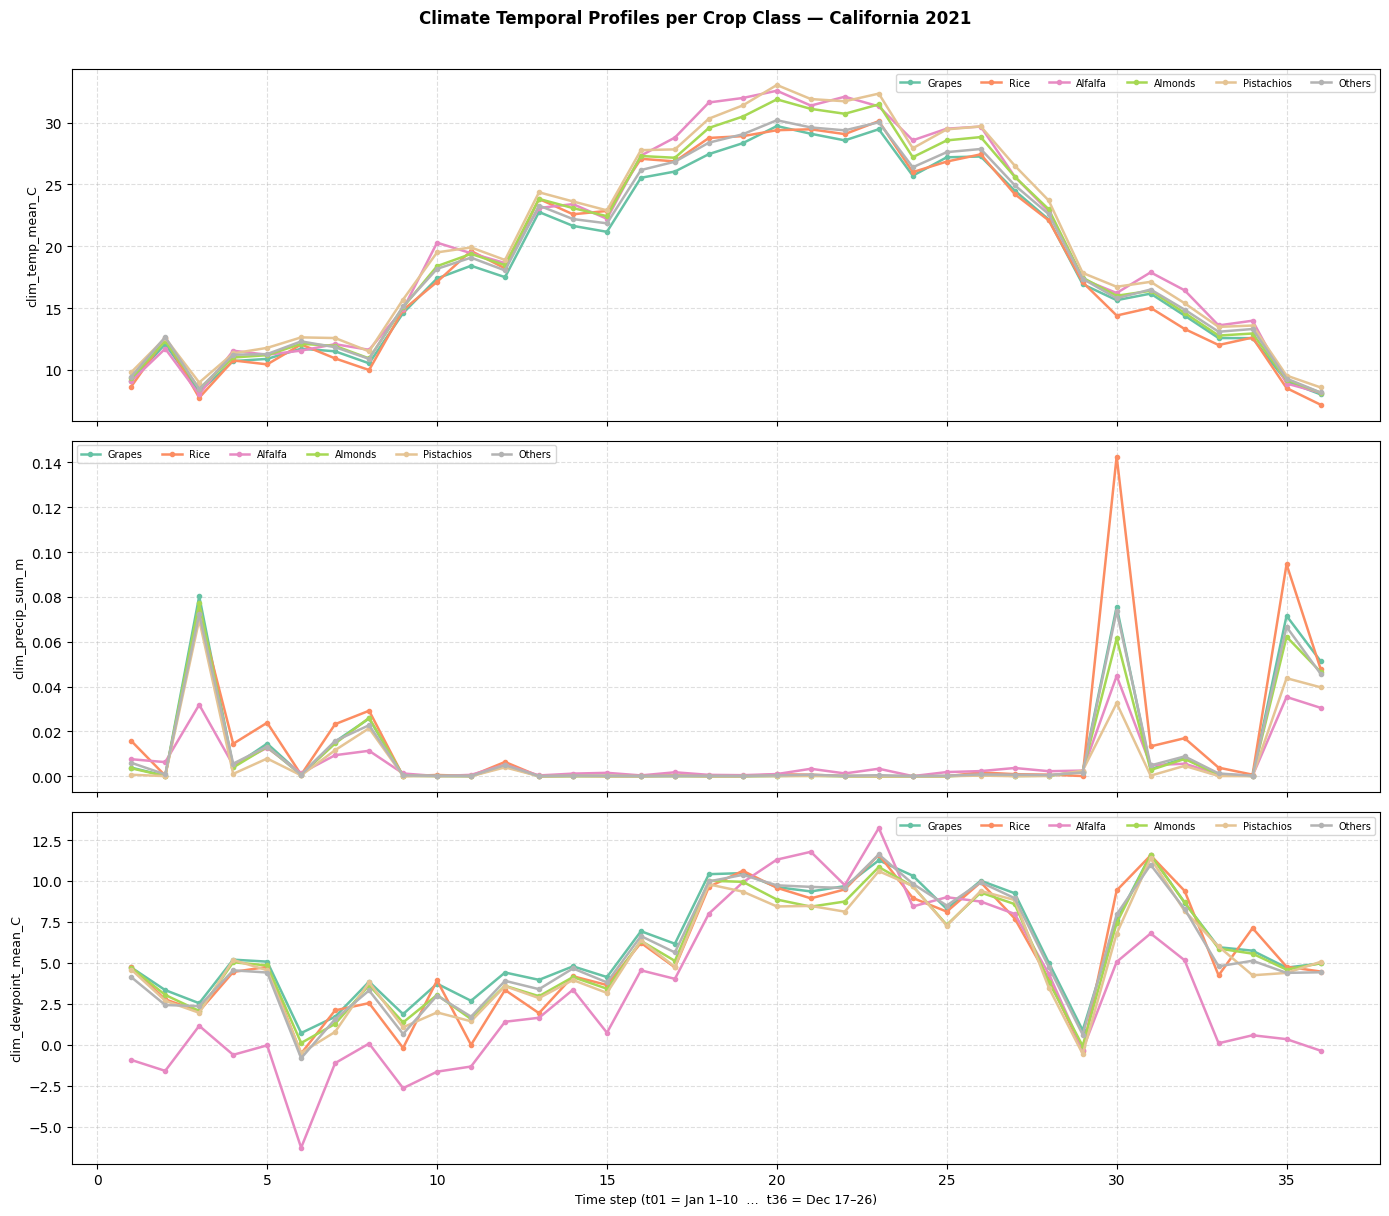

In [59]:
enriched['crop_name'] = enriched['label'].map(label_map)
crop_order  = list(label_map.values())
time_steps  = list(range(1, 37))   # t01 … t36
clim_prefixes = list(dict.fromkeys(ERA5_OUT_PREFIX[b] for b in ERA5_BANDS))

fig, axes = plt.subplots(len(clim_prefixes), 1,
                         figsize=(14, 4 * len(clim_prefixes)), sharex=True)
if len(clim_prefixes) == 1:
    axes = [axes]

colors = plt.cm.Set2(np.linspace(0, 1, len(crop_order)))

for ax, prefix in zip(axes, clim_prefixes):
    for crop, color in zip(crop_order, colors):
        mask  = enriched['crop_name'] == crop
        means = [
            enriched.loc[mask, f'{prefix}_t{t:02d}'].mean()
            for t in time_steps
        ]
        ax.plot(time_steps, means, label=crop, color=color, linewidth=1.8, marker='o', markersize=3)
    ax.set_ylabel(prefix, fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(fontsize=7, ncol=len(crop_order))

axes[-1].set_xlabel('Time step (t01 = Jan 1–10  …  t36 = Dec 17–26)', fontsize=9)
fig.suptitle(f'Climate Temporal Profiles per Crop Class — {STATE} {YEAR}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'clim_temporal_profiles_{STATE}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Validation — Static Feature Distributions per Crop Class

/tmp/ipykernel_1956/2413205325.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=crop_order, patch_artist=True,
/tmp/ipykernel_1956/2413205325.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=crop_order, patch_artist=True,
/tmp/ipykernel_1956/2413205325.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=crop_order, patch_artist=True,
/tmp/ipykernel_1956/2413205325.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will 

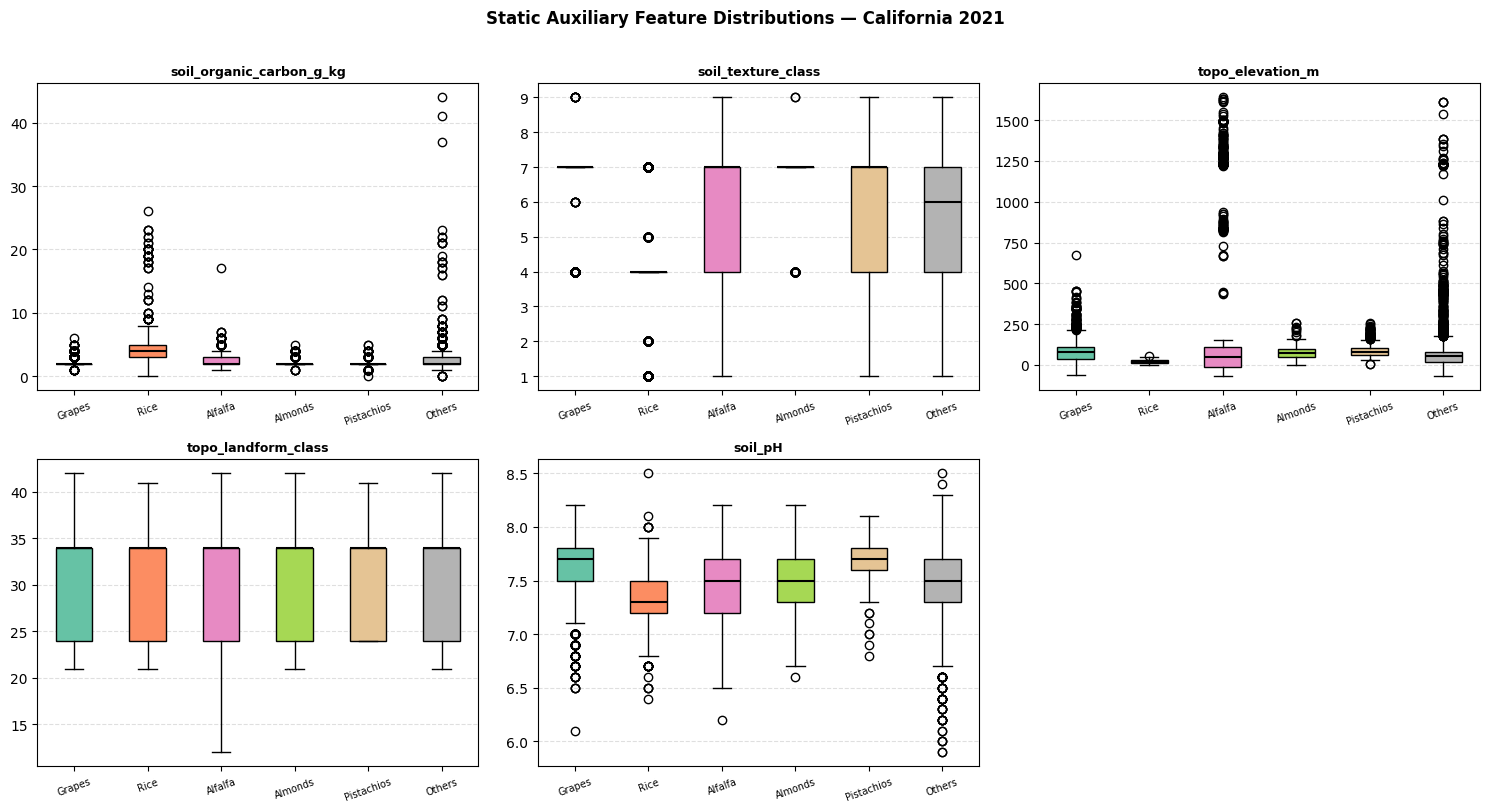

In [60]:
static_aux = [c for c in aux_cols if not c.startswith('clim_')]
ncols = 3
nrows = max(1, (len(static_aux) + ncols - 1) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(static_aux):
    ax   = axes[i]
    data = [enriched.loc[enriched['label'] == lbl, col].dropna().values for lbl in label_map]
    bp   = ax.boxplot(data, labels=crop_order, patch_artist=True,
                      medianprops=dict(color='black', linewidth=1.5))
    cmap = plt.cm.Set2(np.linspace(0, 1, len(crop_order)))
    for patch, color in zip(bp['boxes'], cmap):
        patch.set_facecolor(color)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7, rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Static Auxiliary Feature Distributions — {STATE} {YEAR}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'static_aux_distributions_{STATE}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Final Summary

In [61]:
print('=' * 65)
print(f'  ENRICHED DATASET — {STATE} {YEAR}')
print('=' * 65)
print(f'  Output file      : MCTNet_{STATE}_{YEAR}_enriched_fixed.csv')
print(f'  Total samples    : {len(enriched):,}')
print()
print('  Feature breakdown:')
print(f'    Spectral (S2)        : {len(spectral_cols):>4}  (10 bands × 36 steps)')
print(f'    Validity flags       : {len(valid_cols):>4}')
print(f'    Climate — ERA5       : {len(clim_cols):>4}  ({len(ERA5_BANDS)} bands × 36 steps)')
print(f'    Soil — OpenLandMap   : {len([c for c in soil_topo_cols if c.startswith("soil_")]):>4}')
print(f'    Topo — ETOPO1/ALOS   : {len([c for c in soil_topo_cols if c.startswith("topo_")]):>4}')
print(f'    ─────────────────────────────────────')
print(f'    TOTAL                : {len(spectral_cols)+len(valid_cols)+len(aux_cols):>4}')
print()
print('  Static feature statistics (soil + topo):')
print(enriched[static_aux].describe().round(3).to_string())

  ENRICHED DATASET — California 2021
  Output file      : MCTNet_California_2021_enriched_fixed.csv
  Total samples    : 10,000

  Feature breakdown:
    Spectral (S2)        :  360  (10 bands × 36 steps)
    Validity flags       :   36
    Climate — ERA5       :  108  (3 bands × 36 steps)
    Soil — OpenLandMap   :    3
    Topo — ETOPO1/ALOS   :    2
    ─────────────────────────────────────
    TOTAL                :  509

  Static feature statistics (soil + topo):
       soil_organic_carbon_g_kg  soil_texture_class  topo_elevation_m  topo_landform_class    soil_pH
count                 10000.000           10000.000         10000.000            10000.000  10000.000
mean                      2.749               5.624            91.392               30.366      7.498
std                       1.801               1.738           205.990                5.094      0.305
min                       0.000               1.000           -69.000               12.000      5.900
25%              